In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [12]:
def process_data(data_txt):
    # Read data
    cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']
    cols_widths = [(0,9),(9,26),(27,46),(47,56),(57,66),(67,74),(75,79)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=4, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna()    
    
    # Calculate RA*cos(dec) column
    df_new['RAcosDEC'] = df_new['R.A. (mas)']*np.cos(df_new['Dec. (mas)'])
    
    # Calculate Besselian Year column
    df_new['BY'] = 2000-(51544.333981-df_new['MJD'])/365.242198781
    
    return df_new

In [13]:
df = process_data('ICRF3 Dem/series_ind_dem/1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,45754.258,-1.910705,-1.887599,1.2912,0.7417,-0.084,40,0.595241,1984.147297
1,45759.251,-1.555439,-2.306200,1.2032,1.1362,0.028,19,1.043523,1984.160968
2,45764.244,0.049960,1.459800,0.7069,0.6182,0.325,21,0.005534,1984.174638
3,45769.259,-5.739611,0.890402,2.5316,1.1073,-0.363,25,-3.610785,1984.188369
4,45864.264,-2.973084,0.696002,0.6484,0.6307,0.547,27,-2.281578,1984.448484


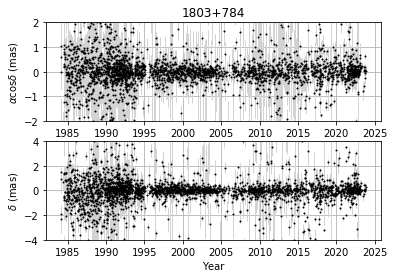

In [14]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df['BY'], df['RAcosDEC'],yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [18]:
def allanoadev(y,dates,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 =  np.mean(np.diff(dates))
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Create weights 
    weights_std = []
    for val in error:
        if val != 0:
            weights_std.append(1/(val**2))
        elif val == 0:
            weights_std.append(0)

    # Iterate over values of m
    for k in range(len(m)): 
        print('Current value of m: ', m[k])
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []
        D = 0
        data_sum = 0
        
        # Check for missing windows 
        while right <= N:
            data_values = y[left:right]
            data_sum = np.sum(data_values)
    
            if data_sum == 0:
                D +=1
            else:
                avg = np.average(data_values, weights=weights_std[left:right])
                ybar.append(avg)
            left += step 
            right += step    
            

        M_D = len(ybar)

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M_D-2*m[k]+1:
            i = j
            ysum = []
            while i <= j+m[k]-1:
                ysum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(ysum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M_D-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [19]:
%%time
tau_dec, allanstd_dec = allanoadev(df['Dec. (mas)'].values,df['MJD'],df['Err. Dec. (mas)'])

Current value of m:  3
Current value of m:  4
Current value of m:  5
Current value of m:  6
Current value of m:  7
Current value of m:  8
Current value of m:  9
Current value of m:  10
Current value of m:  11
Current value of m:  12
Current value of m:  13
Current value of m:  14
Current value of m:  15
Current value of m:  16
Current value of m:  17
Current value of m:  18
Current value of m:  19
Current value of m:  20
Current value of m:  21
Current value of m:  22
Current value of m:  23
Current value of m:  24
Current value of m:  25
Current value of m:  26
Current value of m:  27
Current value of m:  28
Current value of m:  29
Current value of m:  30
Current value of m:  31
Current value of m:  32
Current value of m:  33
Current value of m:  34
Current value of m:  35
Current value of m:  36
Current value of m:  37
Current value of m:  38
Current value of m:  39
Current value of m:  40
Current value of m:  41
Current value of m:  42
Current value of m:  43
Current value of m:  44

In [20]:
tau_year_dec = [x/365.242198781 for x in tau_dec]

Text(0, 0.5, 'Allan std dev in $\\delta$ [microas?]')

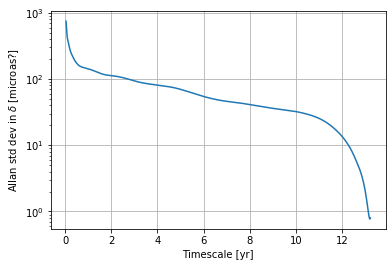

In [22]:
plt.plot(tau_year_dec,allanstd_dec*1000)
plt.yscale('log')
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [microas?]')